Extrayendo datos de Júpiter...


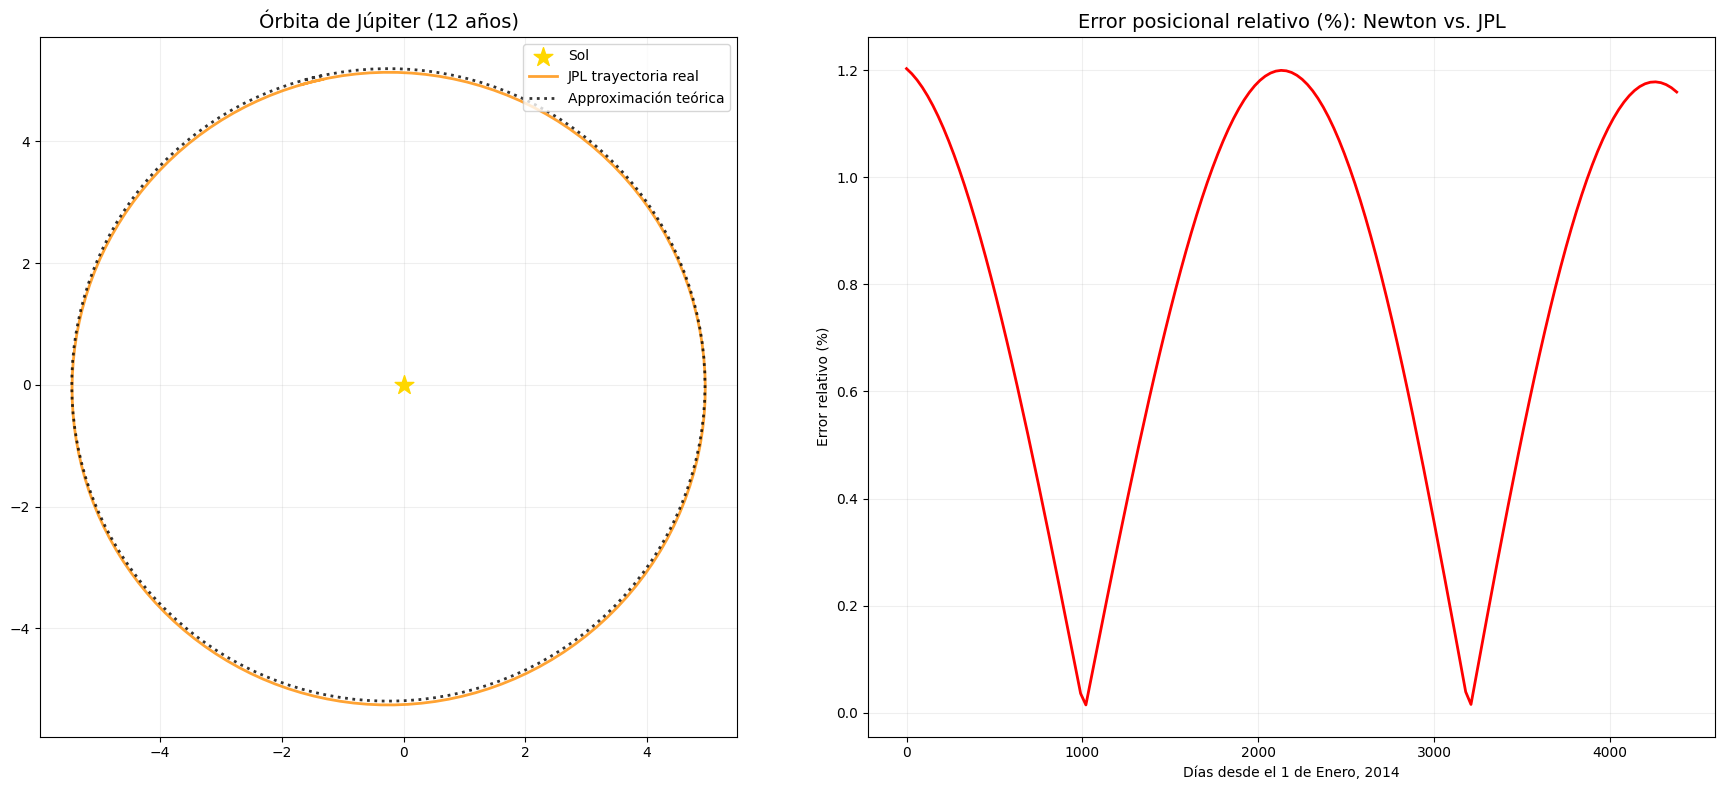

Media del error posicional porcentual: 0.77 %


In [ ]:
!pip install -q astroquery #Instalar en colab la librería para extraer datos de la NASA.
import numpy as np
import matplotlib.pyplot as plt
from astroquery.jplhorizons import Horizons #Cargando dicha librería para extraer datos de la NASA.

# --- Constantes ---
AU_TO_KM = 1.496e+8
G_M_SUN = 0.0002959122
KM_S_CONVERSION = AU_TO_KM / 86400

# 1. Pilla 12 años de datos de la órbita de Júpiter, cogiendo la posición cada mes.
print("Extrayendo datos de Júpiter...")
epochs = {'start': '2014-01-01', 'stop': '2026-01-01', 'step': '30d'}
jup = Horizons(id='599', location='500@10', epochs=epochs).vectors()

# 2. Prepara la estimación Newtoniana usando estimaciones de los parámetros
p_jup = ####
e_jup= ####

# Extraer coordenadas en Unidades Astronómicas (UA)
x_jup_jpl = jup['x']
y_jup_jpl = ####
z_jup_jpl = ####

# Crear el modelo teórico, leyendo los ángulos para coincidir con JPL
phi = np.arctan2(y_jup_jpl,x_jup_jpl)
r_jup = ####
x_jup = r_jup * np.cos(phi)
y_jup = r_jup * np.sin(phi)

# 3. Cálculo de errores relativos
x_diff = ####
y_diff = ####
rel_errors = 100*np.sqrt(x_diff**2 + y_diff**2)/np.sqrt(x_jup_jpl**2 + y_jup_jpl**2)


# 4. Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# --- IZQUIERDA: Comparación de órbitas ---
ax1.scatter(0, 0, color='gold', s=200, marker='*', label='Sol', zorder=5)

# Datos reales de JPL (debajo)
ax1.plot(x_jup_jpl, y_jup_jpl, color='darkorange', lw=2, label='JPL trayectoria real', alpha=0.8)

#Datos modelo teórico
ax1.plot(x_jup, y_jup, 'k:', lw=2, label='Approximación teórica', alpha=0.8)
ax1.set_xlabel("X (UA)")
ax1.set_ylabel("Y (UA)")
ax1.set_title("Órbita de Júpiter (12 años)", fontsize=14)
ax1.set_aspect('equal')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.2)

# --- DERECHA: Gráfica del error ---
days = np.arange(len(rel_errors)) * 30
ax2.plot(days, rel_errors, color='red', lw=2)
ax2.set_title("Error posicional relativo (%): Newton vs. JPL", fontsize=14)
ax2.set_xlabel("Días desde el 1 de Enero, 2014")
ax2.set_ylabel("Error relativo (%)")
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Media del error posicional porcentual: {np.mean(rel_errors):,.2f} %")

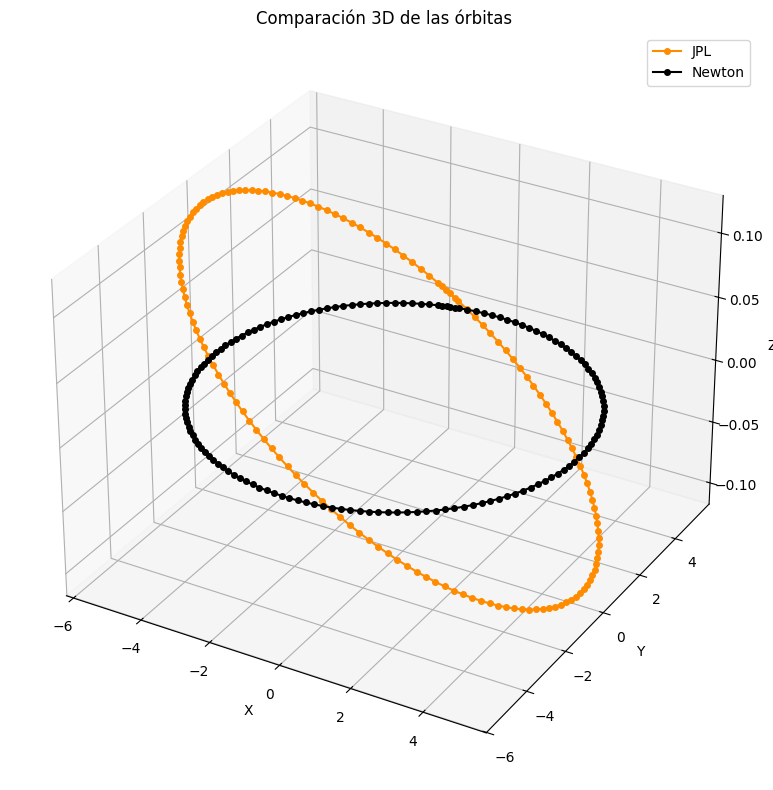

In [ ]:
# Haciendo un plot 3D de la órbita de Júpiter (para ver el error que estamos cometiendo)
fig3d = plt.figure(figsize=(9, 8))
ax3d = fig3d.add_subplot(111, projection='3d')

ax3d.plot(####, ####, ####, label='JPL',
        color='darkorange',
        linestyle='-',
        marker='o',
        markersize=4)
ax3d.plot(####, ####, 0, label='Newton',
        color='black',
        linestyle='-',
        marker='o',
        markersize=4)

# Customizing the chart
ax3d.set_xlabel('X')
ax3d.set_ylabel('Y')
ax3d.set_zlabel('Z')
ax3d.set_title('Comparación 3D de las órbitas')
ax3d.legend()
plt.tight_layout()
plt.show()

Cogiendo mayor parte de los datos de Borisov...


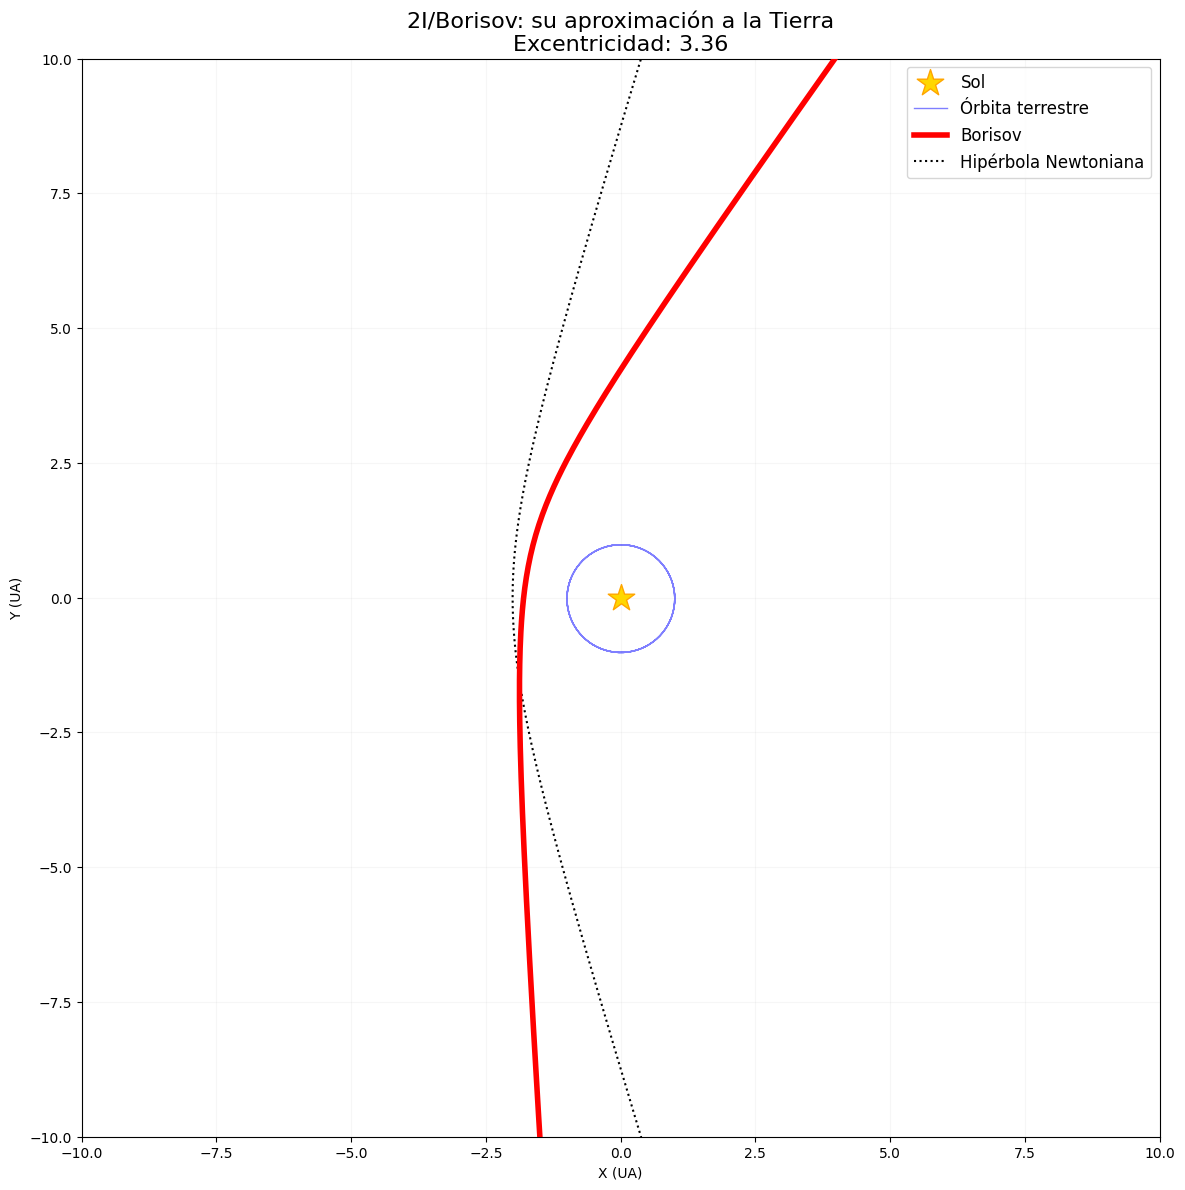

Distancia recorrida con los datos de JPL: 23.81 AU


In [ ]:
# 1. Importa el máximo rango de datos disponibles para 2I-Borisov. Desde principios del 2018 hasta finales del 2022.
# Importa también datos terrestres
print("Cogiendo mayor parte de los datos de Borisov...")
epochs = {'start': '2018-01-01', 'stop': '2022-01-01', 'step': '5d'}
borisov = Horizons(id='2I', location='500@10', epochs=epochs).vectors()
earth = Horizons(id='399', location='500@10', epochs=epochs).vectors()

# 2. Extraemos información de la órbita de Borisov
p_b = 8.74 # Esto cambia dependiendo del punto de la órbita en el que nos fijemos
e_b = ####

# 3. Visualización
fig, ax = plt.subplots(figsize=(14, 14))

# Sol
ax.scatter(0, 0, color='gold', s=400, marker='*', label='Sol', edgecolors='orange', zorder=10)

# Órbita de la Tierra
ax.plot(####, ####, color='blue', lw=1, alpha=0.5, label='Órbita terrestre')

# Trayectoria de Borisov (extraída de JPL)
ax.plot(borisov['x'], ####, color='red', lw=4, label='Borisov', zorder=5)

# Predicción Newtoniana
# El ángulo máximo a considerar viene dado por arccos(-1/e)
limit_theta_hyp = ####

# El periodo que consideraremos será
theta_hyp = np.linspace(-limit_theta_hyp + 0.01, limit_theta_hyp - 0.01, 1000)
r_hyp = ####
x_hyp = ####
y_hyp = ####

# Grafica la versión rotada
ax.plot(x_hyp, y_hyp, color='black', ls=':', lw=1.5, label='Hipérbola Newtoniana')

# Títulos y formato
title_str = (r"2I/Borisov: su aproximación a la Tierra" + "\n" +
             fr"Excentricidad: {e_b:.2f}")
ax.set_title(title_str, fontsize=16)

ax.set_xlabel("X (UA)"), ax.set_ylabel("Y (UA)")
ax.set_xlim(-10, 10), ax.set_ylim(-10, 10) # Deep solar system view
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=12)
ax.grid(True, alpha=0.1)

plt.show()

print(f"Distancia recorrida con los datos de JPL: {np.linalg.norm(np.array([borisov['x'][-1]-borisov['x'][0], borisov['y'][-1]-borisov['y'][0]])):.2f} AU")